# Análisis Exploratorio de Datos

In [80]:
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
import pandas as pd
# pip install pyarrow

### Objetivo 1: Predicción del Retorno del Día Siguiente
- Objetivo: entrenar un modelo de machine learning para predecir si una acción aumentará más de un 1% en los proximos 5 días, utilizando información de los últimos 60 días de datos del mercado del S&P 500 y sus empresas.
- Descripción: el modelo aprovechará indicadores técnicos, acción del precio, dinámica del volumen, medidas de volatilidad y variables rezagadas para aprender patrones de mercado a corto plazo que preceden movimientos positivos significativos del precio. Esta tarea se plantea como un problema de clasificación binaria, donde la variable objetivo indica si el retorno en los siguientes 5 días supera el umbral del 1%.
- Propósito: evaluar la viabilidad de la predicción de retornos a corto plazo utilizando datos históricos de mercado, evitando estrictamente el look-ahead bias y preservando la estructura temporal de las series financieras.

### Origen de los datos y descripción
Los datos de este proyecto provienen de Kaggle, del dataset Advanced Stock Dataset creado por baidalinadilzhan, que a su vez se basa en datos descargados de Yahoo Finance API, cubriendo aproximadamente los últimos cinco años de mercado para los componentes del índice S&P 500. Este conjunto de datos incluye observaciones diarias ajustadas por eventos corporativos como dividendos y splits, y está diseñado específicamente para análisis financiero y modelado de series temporales.
En total, el dataset contiene más de 600 000 registros diarios con 73 características que incluyen precios (Open, High, Low, Close), volumen, indicadores técnicos como medias móviles y RSI, métricas de volatilidad y múltiples variables con información histórica rezagada (lags), lo que lo hace adecuado para tareas de predicción de retornos, clasificación direccional y análisis de riesgo en machine learning financiero.

## Columnas del Dataset
- DATE: Fecha del día de trading. 
- TICKER: Símbolo bursátil de la acción.
- OPEN: Precio de apertura del día.
- HIGH: Precio máximo alcanzado durante el día.
- LOW: Precio mínimo alcanzado durante el día.
- CLOSE: Precio de cierre del día.
- VOLUME: Número total de acciones negociadas.
- DIVIDENDS: Dividendos pagados ese día (si existen).
- STOCK_SPLITS: Split de acciones ocurrido ese día (si existe).
- SMA_5: Media móvil simple del cierre en los últimos 5 días.
- SMA_10: Media móvil simple del cierre en los últimos 10 días.
- SMA_20: Media móvil simple del cierre en los últimos 20 días.
- SMA_50: Media móvil simple del cierre en los últimos 50 días.
- EMA_12: Media móvil exponencial de 12 días.
- EMA_26: Media móvil exponencial de 26 días.
- MACD: Diferencia entre EMA_12 y EMA_26 (indicador de momentum).
- MACD_SIGNAL: Media móvil del MACD.
- MACD_HISTOGRAM: Diferencia entre MACD y su señal.
- RSI: Índice de Fuerza Relativa (14 periodos).
- VOLATILITY: Volatilidad histórica del precio.
- BB_MIDDLE: Banda central de Bollinger (media móvil).
- BB_UPPER: Banda superior de Bollinger.
- BB_LOWER: Banda inferior de Bollinger.
- BB_WIDTH: Ancho de las bandas de Bollinger (medida de volatilidad relativa).
- BB_POSITION: Posición del precio dentro de las bandas de Bollinger.
- PRICE_CHANGE: Cambio diario del precio de cierre.
- PRICE_CHANGE_5D: Cambio acumulado del precio en los últimos 5 días.
- HIGH_LOW_RATIO: Relación entre precio máximo y mínimo.
- OPEN_CLOSE_RATIO: Relación entre apertura y cierre.
- VOLUME_SMA: Media móvil del volumen.
- VOLUME_RATIO: Volumen actual comparado con su media.
- CLOSE_LAG_1: Precio de cierre de hace 1 día.
- CLOSE_LAG_2: Precio de cierre de hace 2 días.
- CLOSE_LAG_3: Precio de cierre de hace 3 días.
- CLOSE_LAG_4: Precio de cierre de hace 4 días.
- CLOSE_LAG_5: Precio de cierre de hace 5 días.
- CLOSE_LAG_6: Precio de cierre de hace 6 días.
- CLOSE_LAG_7: Precio de cierre de hace 7 días.
- CLOSE_LAG_8: Precio de cierre de hace 8 días.
- CLOSE_LAG_9: Precio de cierre de hace 9 días.
- CLOSE_LAG_10: Precio de cierre de hace 10 días.
- VOLUME_LAG_1: Volumen de hace 1 día.
- VOLUME_LAG_2: Volumen de hace 2 días.
- VOLUME_LAG_3: Volumen de hace 3 días.
- VOLUME_LAG_4: Volumen de hace 4 días.
- VOLUME_LAG_5: Volumen de hace 5 días.
- VOLUME_LAG_6: Volumen de hace 6 días.
- VOLUME_LAG_7: Volumen de hace 7 días.
- VOLUME_LAG_8: Volumen de hace 8 días.
- VOLUME_LAG_9: Volumen de hace 9 días.
- VOLUME_LAG_10: Volumen de hace 10 días.
- PRICE_CHANGE_LAG_1: Cambio de precio de hace 1 día.
- PRICE_CHANGE_LAG_2: Cambio de precio de hace 2 días.
- PRICE_CHANGE_LAG_3: Cambio de precio de hace 3 días.
- PRICE_CHANGE_LAG_4: Cambio de precio de hace 4 días.
- PRICE_CHANGE_LAG_5: Cambio de precio de hace 5 días.
- PRICE_CHANGE_LAG_6: Cambio de precio de hace 6 días.
- PRICE_CHANGE_LAG_7: Cambio de precio de hace 7 días.
- PRICE_CHANGE_LAG_8: Cambio de precio de hace 8 días.
- PRICE_CHANGE_LAG_9: Cambio de precio de hace 9 días.
- PRICE_CHANGE_LAG_10: Cambio de precio de hace 10 días.
- RSI_LAG_1: RSI de hace 1 día.
- RSI_LAG_2: RSI de hace 2 días.
- RSI_LAG_3: RSI de hace 3 días.
- RSI_LAG_4: RSI de hace 4 días.
- RSI_LAG_5: RSI de hace 5 días.
- MACD_LAG_1: MACD de hace 1 día.
- MACD_LAG_2: MACD de hace 2 días.
- MACD_LAG_3: MACD de hace 3 días.
- MACD_LAG_4: MACD de hace 4 días.
- MACD_LAG_5: MACD de hace 5 días.
- VOLATILITY_LAG_1: Volatilidad de hace 1 día.
- VOLATILITY_LAG_2: Volatilidad de hace 2 días.
- FUTURE_RETURN_1D / 5D / 10D / 20D: Retorno futuro a N días.
- FUTURE_UP_1D / 5D / 10D / 20D: Variable binaria (1 si sube, 0 si no).
- FUTURE_CATEGORY_1D / 5D / 10D / 20D: Categoría del retorno futuro.

## Cargar datos y crear DataFrame

In [81]:
# Definir ruta donde estan los archivos
path = r'../data/raw/'

In [82]:
# Listar archivos Parquet que comienzan con 'data'
all_files = glob.glob(os.path.join(path, 'data*.parquet'))

In [83]:
# Leer cada archivo Parquet y almacenarlo en una lista de DataFrames
df_list = []
for filename in all_files:
    df_part = pd.read_parquet(filename, engine='pyarrow')
    df_list.append(df_part)

In [84]:
# Concatenar todos los DataFrames en un único DataFrame
df = pd.concat(df_list, axis=0, ignore_index=True)

In [85]:
# Convertimos Date a datetime (necesario para split temporal)
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\USER\AppData\Local\Temp\ipykernel_6544\1063807796.py:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'])


## Análisis descriptivo

In [86]:
# Mostrar las primeras filas del dataset
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,SMA_5,...,Future_Category_1d,Future_Return_5d,Future_Up_5d,Future_Category_5d,Future_Return_10d,Future_Up_10d,Future_Category_10d,Future_Return_20d,Future_Up_20d,Future_Category_20d
0,2020-09-08 00:00:00-04:00,93.113965,93.462744,91.806050,92.174202,1225600,0.0,0.0,A,96.138635,...,3.0,0.054972,1,3.0,0.036578,1,3.0,0.070141,1,3.0
1,2020-09-09 00:00:00-04:00,93.104280,95.400403,92.871764,94.877235,954400,0.0,0.0,A,95.520526,...,2.0,0.020321,1,3.0,-0.010416,0,1.0,0.062670,1,3.0
2,2020-09-10 00:00:00-04:00,95.797603,96.979573,95.177554,95.497269,1933200,0.0,0.0,A,94.580765,...,2.0,0.010449,1,2.0,-0.022623,0,0.0,0.058616,1,3.0
3,2020-09-11 00:00:00-04:00,95.632924,96.514560,94.964430,95.526352,1368600,0.0,0.0,A,94.379250,...,2.0,0.007911,1,2.0,-0.009229,0,1.0,0.074550,1,3.0
4,2020-09-14 00:00:00-04:00,96.621112,97.105525,95.884801,96.320770,1207700,0.0,0.0,A,94.879166,...,2.0,-0.012975,0,1.0,0.000905,1,2.0,0.062363,1,3.0


In [87]:
# Ver el número de filas y columnas
df.shape

(620095, 73)

In [88]:
# Mostrar los nombres de las columnas del DataFrame
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits', 'Ticker', 'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50',
       'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'RSI',
       'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'BB_Position',
       'Volatility', 'Price_Change', 'Price_Change_5d', 'High_Low_Ratio',
       'Open_Close_Ratio', 'Volume_SMA', 'Volume_Ratio', 'Close_lag_1',
       'Close_lag_2', 'Close_lag_3', 'Close_lag_5', 'Close_lag_10',
       'Volume_lag_1', 'Volume_lag_2', 'Volume_lag_3', 'Volume_lag_5',
       'Volume_lag_10', 'Price_Change_lag_1', 'Price_Change_lag_2',
       'Price_Change_lag_3', 'Price_Change_lag_5', 'Price_Change_lag_10',
       'RSI_lag_1', 'RSI_lag_2', 'RSI_lag_3', 'RSI_lag_5', 'RSI_lag_10',
       'MACD_lag_1', 'MACD_lag_2', 'MACD_lag_3', 'MACD_lag_5', 'MACD_lag_10',
       'Volatility_lag_1', 'Volatility_lag_2', 'Volatility_lag_3',
       'Volatility_lag_5', 'Volatility_lag_10', 'Future_Return_1d',

In [89]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_5,SMA_10,SMA_20,...,Future_Category_1d,Future_Return_5d,Future_Up_5d,Future_Category_5d,Future_Return_10d,Future_Up_10d,Future_Category_10d,Future_Return_20d,Future_Up_20d,Future_Category_20d
count,620095.000000,620095.000000,620095.000000,620095.000000,6.200950e+05,620095.000000,620095.000000,620095.000000,620095.000000,620095.000000,...,620095.000000,620095.000000,620095.000000,620095.000000,620095.000000,620095.000000,620095.000000,620095.000000,620095.000000,620095.000000
mean,170.627414,172.655990,168.572121,170.644869,6.096960e+06,0.008466,0.000509,170.468481,170.252508,170.507352,...,1.529230,0.003469,0.537629,1.601787,0.006701,0.544675,1.638134,0.013391,0.546842,1.671147
std,348.798425,352.931455,344.794251,348.874888,2.343659e+07,0.150236,0.088409,348.389490,347.815938,348.346822,...,0.833302,0.045223,0.498582,1.171758,0.063206,0.498001,1.270877,0.089116,0.497801,1.341019
min,2.216000,2.318000,2.195000,2.225000,0.000000e+00,0.000000,0.000000,2.282600,2.405400,2.571350,...,0.000000,-0.587245,0.000000,0.000000,-0.605622,0.000000,0.000000,-0.641508,0.000000,0.000000
25%,54.084445,54.752876,53.418879,54.089727,1.006000e+06,0.000000,0.000000,54.064695,54.001021,54.123933,...,1.000000,-0.020331,0.000000,0.000000,-0.028207,0.000000,0.000000,-0.038917,0.000000,0.000000
50%,100.756525,102.024624,99.501965,100.802925,2.122600e+06,0.000000,0.000000,100.693167,100.565018,100.708299,...,2.000000,0.003506,1.000000,2.000000,0.006120,1.000000,2.000000,0.010784,1.000000,2.000000
75%,193.751534,196.013628,191.432234,193.721542,4.888700e+06,0.000000,0.000000,193.624097,193.474001,193.834851,...,2.000000,0.026855,1.000000,3.000000,0.040424,1.000000,3.000000,0.061390,1.000000,3.000000
max,9914.169922,9964.769531,9794.000000,9924.400391,1.543911e+09,75.000000,50.000000,9814.860156,9693.651074,9672.676465,...,3.000000,0.784177,1.000000,3.000000,1.260495,1.000000,3.000000,2.223735,1.000000,3.000000


In [90]:
# Información general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 620095 entries, 0 to 620094
Data columns (total 73 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Date                 620095 non-null  object 
 1   Open                 620095 non-null  float64
 2   High                 620095 non-null  float64
 3   Low                  620095 non-null  float64
 4   Close                620095 non-null  float64
 5   Volume               620095 non-null  int64  
 6   Dividends            620095 non-null  float64
 7   Stock Splits         620095 non-null  float64
 8   Ticker               620095 non-null  object 
 9   SMA_5                620095 non-null  float64
 10  SMA_10               620095 non-null  float64
 11  SMA_20               620095 non-null  float64
 12  SMA_50               620095 non-null  float64
 13  EMA_12               620095 non-null  float64
 14  EMA_26               620095 non-null  float64
 15  MACD             

In [91]:
# Contar valores nulos por columna
df.isnull().sum().sort_values(ascending=False)

Date                   0
Volume_lag_2           0
MACD_lag_3             0
MACD_lag_2             0
MACD_lag_1             0
                      ..
Volatility             0
BB_Position            0
BB_Width               0
BB_Lower               0
Future_Category_20d    0
Length: 73, dtype: int64

### Observaciones
- El dataset tiene un total de 620,095 filas.
- Cuenta con 73 columnas en total.
- No se han encontrado filas duplicadas en el dataset.
- No hay valores nulos en ninguna columna.
- De las 73 columnas, 71 son de tipo numérico.
- Dos columnas son de tipo objeto.

## Limpieza de Datos

In [92]:
# Eliminamos columnas que no serán utilizadas inicialmente para el análisis exploratorio ni para el modelado.
df = df.drop(['Dividends', 'Stock Splits', 'SMA_10', 'SMA_50', 'MACD_Histogram', 'BB_Middle',
              'BB_Width', 'Price_Change_5d', 'High_Low_Ratio', 'Open_Close_Ratio', 'Volume_SMA',
              'Close_lag_5', 'Close_lag_10','Price_Change_lag_1', 'Price_Change_lag_2',
              'Price_Change_lag_3', 'Price_Change_lag_5', 'Price_Change_lag_10', 'RSI_lag_2', 'RSI_lag_3', 'RSI_lag_5', 'RSI_lag_10',
              'MACD_lag_2', 'MACD_lag_3', 'MACD_lag_5', 'MACD_lag_10', 'Future_Category_1d', 'Future_Return_5d',
              'Future_Up_1d', 'Future_Category_5d', 'Future_Return_10d','Future_Up_10d', 'Future_Category_10d', 
              'Future_Return_20d', 'Future_Up_20d', 'Future_Category_20d','Future_Return_1d'], axis=1)

### Observaciones
Se eliminaron las columnas que no aportan información relevante para el objetivo principal del análisis y modelado, como métricas a largo plazo, indicadores redundantes o futuros retornos de 5, 10 y 20 días, para simplificar el dataset y evitar data leakage. Se eligió Future_Up_1d como variable objetivo porque representa de manera binaria si la acción subirá al menos un 1 % al día siguiente, alineándose directamente con el objetivo del modelo.

In [93]:
# Contar cuántos valores cero hay en cada columna del DataFrame.
value_cero = (df == 0).sum()

In [94]:
# Mostrar solo las columnas que contienen al menos un valor cero
value_cero[value_cero > 0]

Volume                2
RSI                   9
Price_Change       2306
Volume_Ratio          2
Volume_lag_1          2
Volume_lag_2          2
Volume_lag_3          2
Volume_lag_5          2
Volume_lag_10         2
RSI_lag_1             9
Future_Up_5d     286714
dtype: int64

In [95]:
# Revisar la distribución de los valores de la columna 'Price_Change'
df['Price_Change'].value_counts()

Price_Change
 0.000000    2306
 0.001779       4
 0.006711       3
 0.003836       3
-0.005344       3
             ... 
-0.019073       1
 0.008548       1
 0.012201       1
-0.004969       1
-0.003052       1
Name: count, Length: 616962, dtype: int64

### Observaciones
Se comprueba la cantidad de ceros en el dataset para asegurarnos de que no representan errores o datos faltantes. Aunque Price_Change tiene varios ceros, esto es esperado y consistente con los movimientos reales de precio; por lo tanto, no se consideran anomalías.

## Visualización

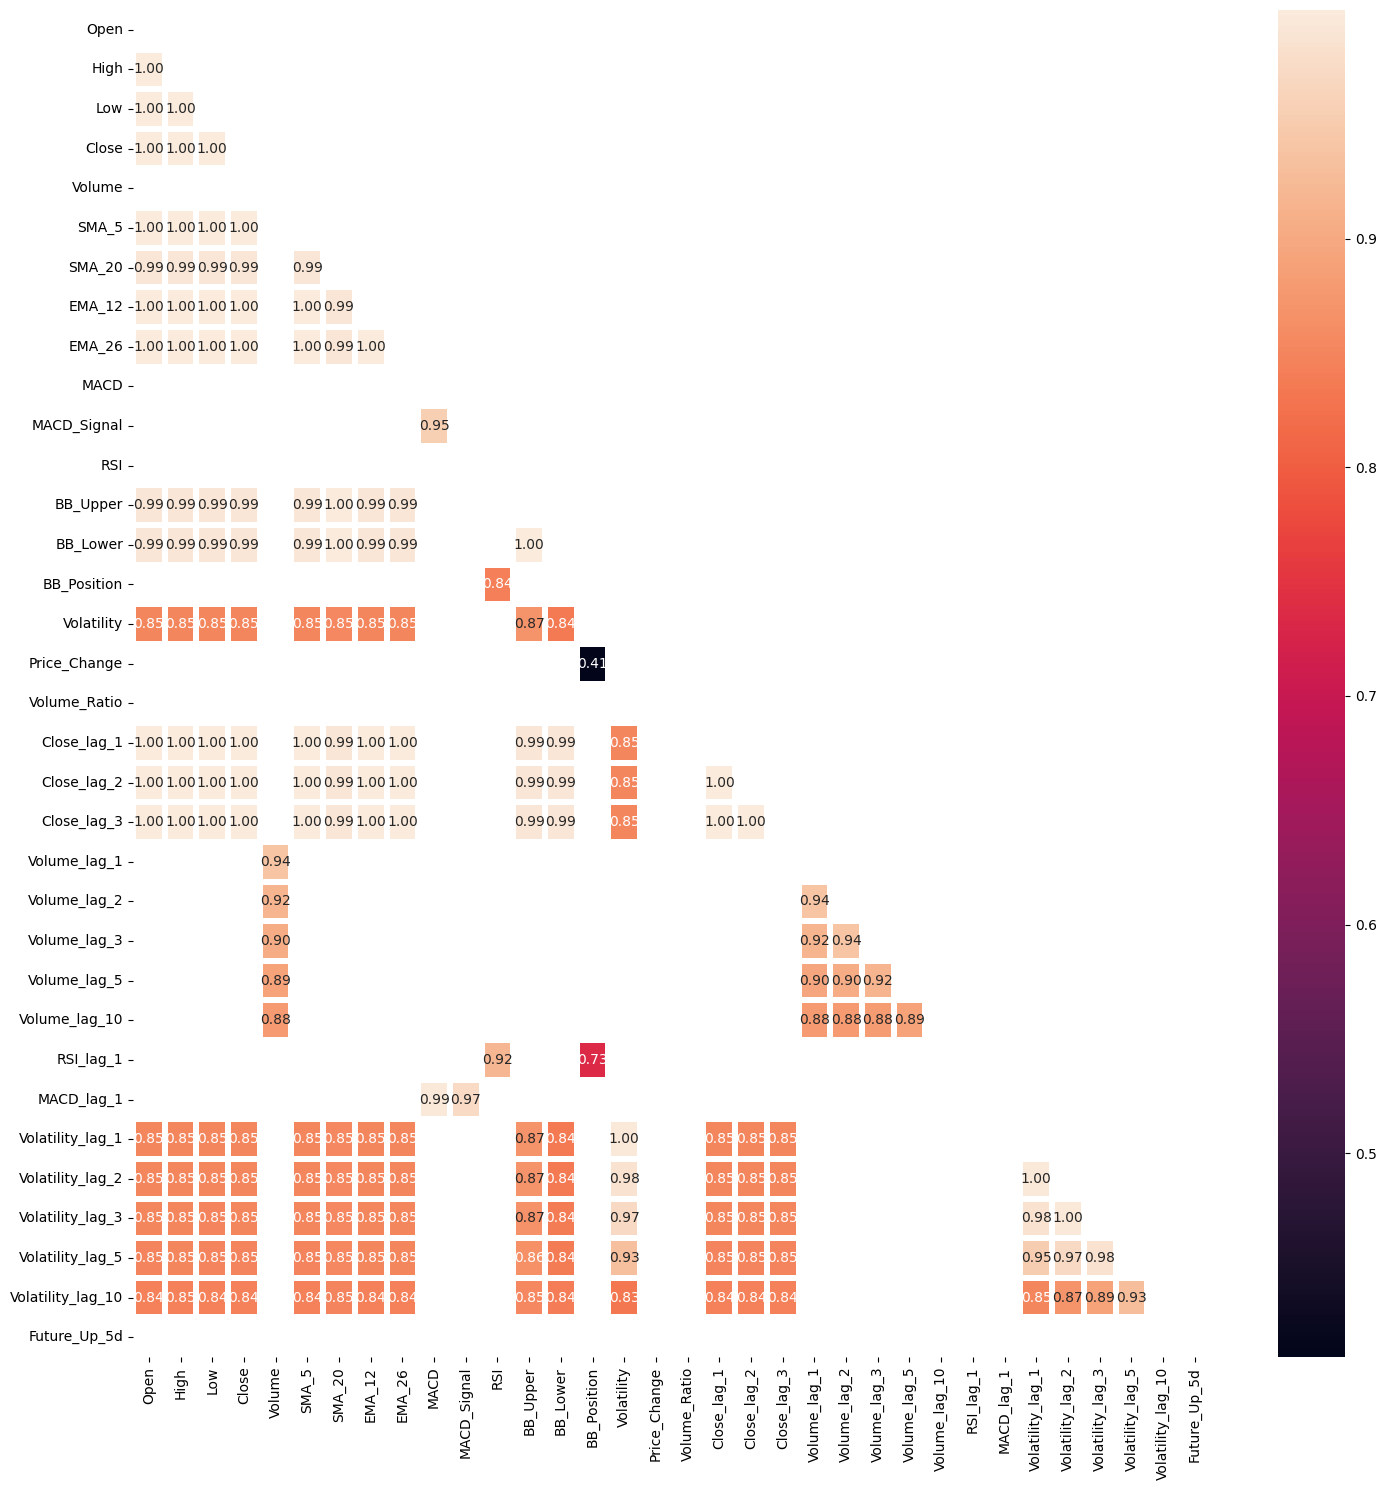

In [96]:
# Creamos un DataFrame solo con columnas numéricas (excluyendo 'Ticker' y 'Date')
df_filtrado = df.drop(columns=['Ticker','Date'])

# Calculamos la matriz de correlación entre las variables numéricas
corr_numerical = df_filtrado.corr(numeric_only=True)

# Filtramos correlaciones fuertes y preparamos la máscara para la mitad superior
high_correlation = corr_numerical[corr_numerical.abs() > 0.40]
mask = np.triu(np.ones_like(corr_numerical, dtype=bool))

# Graficamos el mapa de calor de correlaciones
fig, axis = plt.subplots(figsize=(15,15))
sns.heatmap(high_correlation, annot=True, mask=mask, linewidths=3, fmt='.2f')

plt.tight_layout()
plt.show()

In [97]:
# Eliminamos columnas altamente redundantes detectadas en el mapa de calor de correlaciones
cols_to_drop = ['Open', 'High', 'Low', 'SMA_5', 'SMA_20', 'EMA_26', 'Close_lag_1', 'Close_lag_2',
                'Close_lag_3', 'Volatility_lag_2', 'Volatility_lag_3', 'Volatility_lag_5', 'Volatility_lag_10']

df = df.drop(columns=cols_to_drop)

### Observaciones
Se eliminaron estas columnas porque presentaban correlaciones muy altas (0.85 o superiores) con otras variables, lo que indica redundancia y riesgo de multicolinealidad. Ninguna de ellas mostraba relación directa con el target Future_Up_1d, por lo que su eliminación permite simplificar el dataset sin perder información relevante para el modelado.

## Ingeniería de Variables

In [98]:
# Ordenar por fecha
df = df.sort_values(['Ticker', 'Date']) 

# Momentum (retorno 5 días)
df['retorno_5d'] = df.groupby('Ticker')['Close'].pct_change(5)

# Volatilidad (desviación estándar móvil)
df['volatilidad_10d'] = df.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=10).std())

# RSI
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI'] = df.groupby('Ticker')['Close'].transform(lambda x: calculate_rsi(x))

In [99]:
# Cruce de MACD
df['MACD_Bullish'] = (df['MACD'] > df['MACD_Signal']).astype(int)

# Tendencia del RSI
df['RSI_Trend_Up'] = (df['RSI'] > df['RSI_lag_1']).astype(int)

# Ruptura de Bandas de Bollinger
df['BB_Breakout'] = 0
df.loc[df['Close'] > df['BB_Upper'], 'BB_Breakout'] = 1
df.loc[df['Close'] < df['BB_Lower'], 'BB_Breakout'] = -1

# Momentum de Volumen
df['High_Volume_Signal'] = (df['Volume'] > df.groupby('Ticker')['Volume'].transform(lambda x: x.rolling(5).mean())).astype(int)

# Limpieza post ingeniería
df_final = df.dropna().copy()

In [100]:
# Verificamos cómo se relaciona el target 'Future_Up_5d' con el cambio de precio en los próximos 5 días
verificacion = df_final[['Ticker','Price_Change', 'Future_Up_5d','Date']].copy()

In [101]:
# Retorno acumulado real de los próximos 5 días
verificacion['Next_5d_Change'] = verificacion.groupby('Ticker')['Price_Change'].transform(lambda x: x.shift(-1).rolling(5).sum())

In [102]:
# Cambio promedio cuando el target es 1
verificacion[verificacion['Future_Up_5d'] == 1]['Next_5d_Change'].mean()

0.00848077028096802

In [103]:
# Eliminamos la columna Ticker (mucho ruido)
df_final = df_final.drop(columns='Ticker')

## Split Temporal

In [104]:
# Definimos fecha de corte (80% más antiguo para train)
split_date = df_final['Date'].quantile(0.8)

In [105]:
# Creamos datasets temporales
train_df = df_final[df_final['Date'] <= split_date]
test_df  = df_final[df_final['Date'] > split_date]

In [106]:
# Definimos X, y, y eliminamos Date
X_train = train_df.drop(columns=['Future_Up_5d','Date'])
y_train = train_df['Future_Up_5d']

X_test = test_df.drop(columns=['Future_Up_5d','Date'])
y_test = test_df['Future_Up_5d']

## Standard Scaler

In [107]:
# Instanciamos el Scaler
scaler = StandardScaler()

# Ajustamos con los datos completos (numéricos + ticker encoded)
scaler.fit(X_train)

# Transformamos ambos conjuntos
X_train_scaled_array = scaler.transform(X_train)
X_test_scaled_array  = scaler.transform(X_test)

# Convertimos de nuevo a DataFrame para mantener el orden y nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=X_test.columns, index=X_test.index)

## Guardar datos de entrenamiento y prueba

In [108]:
# Guardar los conjuntos de prueba y entrenamiento procesados como archivos CSV
X_train_scaled.to_csv("../data/processed/X_train_eda5_obj1.csv", index = False)
X_test_scaled.to_csv("../data/processed/X_test_eda5_obj1.csv", index = False)
y_train.to_csv("../data/processed/y_train_eda5_obj1.csv", index = False)
y_test.to_csv("../data/processed/y_test_eda5_obj1.csv", index = False)